# Chunk 15 — Fine-Tuned Evaluation

Evaluate and compare three models on the multi-scale (35/45/55) held-out test set:

| Model | Source | Training data |
|-------|--------|---------------|
| Zero-shot | `best_model.pt` (Chunk 7) | 25×25 only |
| Fine-tuned @2,000 | `strategy_A.pt` (Chunk 13) | 2,000-sample grid-stratified subset |
| Ceiling (full pool) | `ceiling_fullpool.pt` (this notebook) | Full pool (~11,971 samples) |

**Scope note.** Chunk 14 (active learning) is DEFERRED. No AL result is claimed.
The "fine-tuned" model is Chunk 13's Strategy A — a random-acquisition fine-tuned
model at budget 2,000. The ceiling model is trained here on the full pool and
promoted to `gnn_finetuned_multiscale.pt` so Chunk 16 loads without edits. A
provenance file records that this is NOT an AL-promoted arm.

## 1. Environment Setup & Dependencies

Install the required Python packages.

In [1]:
# Cell 1 — Install dependencies
!pip install scipy numpy matplotlib torch torchvision \
    torch-geometric tqdm scikit-learn pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.1 MB/s eta 0:00:00


## 2. Repository Setup

Clone the GitHub repository to the local Colab environment and add `src` to the Python path.

In [2]:
# Cell 2 — Clone repo (re-clones every session; pulls latest if already exists)
import os
REPO_ROOT = '/content/antenna-gnn'
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull --quiet
import sys
sys.path.insert(0, f'{REPO_ROOT}/src')   # makes 'from model import AntennaGNN' work
print(f'Repo ready at {REPO_ROOT}')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 285, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (160/160), done.
remote: Total 285 (delta 150), reused 243 (delta 110), pack-reused 0 (from 0)
Receiving objects: 100% (285/285), 5.82 MiB | 21.67 MiB/s, done.
Resolving deltas: 100% (150/150), done.
Repo ready at /content/antenna-gnn


## 3. Drive Mount and Path Configuration

Mount Google Drive to access `RAW_DATA` and store checkpoints and artifacts in `DATA_ROOT`.

In [3]:
# Cell 3 — Mount Drive and set data paths
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'
for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints',
          f'{DATA_ROOT}/figures',   f'{DATA_ROOT}/splits',
          f'{DATA_ROOT}/data/processed', f'{DATA_ROOT}/data/processed_finetune']:
    os.makedirs(d, exist_ok=True)
print(f'Drive mounted. DATA_ROOT={DATA_ROOT}')

Mounted at /content/drive
Drive mounted. DATA_ROOT=/content/drive/MyDrive/antenna_gnn


---
## CELL A — Setup and Normalization Guard

Load `FinetuneDataset` (frozen from Chunk 13), training utilities, splits, statistics,
and strategy config. Build val and test loaders over the FULL val/test sets. Run the
canonical normalization guard (identity version).

In [4]:
# CELL A — Setup and normalization guard
import json
import shutil
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from collections import defaultdict
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
from tqdm.notebook import tqdm
from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── FinetuneDataset — frozen — validated in Chunk 13 ──
class FinetuneDataset(TorchDataset):
    """Fine-tune graph dataset with mandatory z-score normalization at load.

    On-disk data.y is raw dB. This dataset z-scores y at load time using
    the 25x25 training-split s11_mean / s11_std, and preserves y_raw.
    evaluate() de-normalizes with the same statistics.

    Never pass s11_mean=None or s11_std=None.
    """

    def __init__(self, indices, processed_dir_base, s11_mean, s11_std):
        assert s11_mean is not None, 'FinetuneDataset requires s11_mean (got None)'
        assert s11_std is not None,  'FinetuneDataset requires s11_std (got None)'
        self.indices = indices
        self.processed_dir_base = processed_dir_base
        self.s11_mean = s11_mean   # (201,) tensor
        self.s11_std  = s11_std    # (201,) tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        grid_size, local_idx = self.indices[idx]
        path = f'{self.processed_dir_base}/{grid_size}x{grid_size}/sample_{local_idx}.pt'
        data = torch.load(path, weights_only=False)

        # Preserve raw dB target, then z-score
        data.y_raw = data.y.clone()                              # (1, 201) raw dB
        data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)  # (1, 201) normalized

        return data


# ── train_finetune() — frozen — validated in Chunk 13 ──
def compute_weighted_val_mae(metrics, val_indices):
    """Sample-weighted S11 MAE: weight each grid by its share of the val set."""
    grid_counts = defaultdict(int)
    for g, _ in val_indices:
        grid_counts[g] += 1
    total = sum(grid_counts.values())
    matched = [g for g in metrics if g in grid_counts]
    # Without this, a key-type mismatch (int 35 vs str '35' from JSON) makes
    # the generator empty and sum() returns 0.0 — a silent, plausible-looking
    # zero rather than an error.
    assert matched, (
        f'no grid keys shared between metrics {list(metrics)} and indices '
        f'{list(grid_counts)} — key type mismatch, weighted MAE would be 0.0')
    weighted = sum(
        metrics[g]['s11_mae'] * grid_counts[g] / total
        for g in matched
    )
    return weighted


def train_finetune(model, train_loader, val_loader, epochs=40, lr=1e-4,
                   patience=8, max_norm=1.0):
    """Fine-tune model with Adam + ReduceLROnPlateau + gradient clipping.

    Selects on sample-weighted val S11 MAE. Returns
    (model, best_val_mae, epochs_run, grad_norms).
    """
    # frozen — validated in Chunk 13
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = torch.optim.Adam(trainable, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=4, min_lr=1e-6)
    criterion = nn.MSELoss()

    best_val_mae = float('inf')
    best_state = None
    epochs_no_improve = 0
    grad_norms = []  # pre-clip total norm for every step

    for epoch in tqdm(range(epochs), desc="Training Epochs"):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Batches", leave=False):
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch)
            loss = criterion(pred, batch.y.squeeze(1))
            loss.backward()

            # Capture pre-clip gradient norm (the value RETURNED by clip_grad_norm_)
            pre_clip_norm = clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_norm
            ).item()
            grad_norms.append(pre_clip_norm)

            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches

        # Validate
        val_metrics = evaluate(model, val_loader)
        val_mae = compute_weighted_val_mae(val_metrics, val_indices)
        scheduler.step(val_mae)

        current_lr = optimizer.param_groups[0]['lr']
        clip_frac_epoch = (np.array(grad_norms[-n_batches:]) > max_norm).mean() * 100
        print(f'  Epoch {epoch+1:2d}: loss={avg_loss:.4f}  '
              f'w_val_mae={val_mae:.4f}  lr={current_lr:.2e}  '
              f'grad_norm_median={np.median(grad_norms[-n_batches:]):.3f}  '
              f'clip_frac={clip_frac_epoch:.1f}%')

        # Divergence guard: NaN < inf is False, so without this a diverged run
        # leaves best_state = None and crashes on load_state_dict(None) only
        # after `patience` wasted epochs.
        if not np.isfinite(val_mae):
            print(f'  Epoch {epoch+1}: weighted val MAE is {val_mae} — '
                  f'aborting this strategy (divergence)')
            break

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    if best_state is None:
        raise RuntimeError(
            'training never produced a finite validation MAE — likely divergence. '
            'Check the learning rate and re-run the normalization guard.')

    # Restore best
    model.load_state_dict(best_state)
    model.to(device)
    epochs_run = epoch + 1
    return model, best_val_mae, epochs_run, grad_norms


def print_grad_stats(grad_norms, max_norm, strategy_name):
    """Print gradient norm distribution for a strategy."""
    # frozen — validated in Chunk 13
    gn = np.array(grad_norms)
    clip_frac = (gn > max_norm).mean() * 100
    print(f'  Gradient norms ({strategy_name}, max_norm={max_norm}):')
    print(f'    median={np.median(gn):.3f}  p90={np.percentile(gn, 90):.3f}  '
          f'max={gn.max():.3f}  clip_fraction={clip_frac:.1f}%')
    return clip_frac


def print_depth_diagnostics(metrics, label):
    """Print resonance-depth error alongside S11 MAE."""
    # frozen — validated in Chunk 13
    print(f'\n  Resonance depth diagnostics ({label}):')
    print(f'  {"Grid":<6} {"med(pred min)":>14} {"med(true min)":>14} '
          f'{"depth_err":>10} {"det_rate":>10}')
    for g in sorted(metrics.keys()):
        m = metrics[g]
        de = f"{m['depth_error']:.2f}" if not np.isnan(m['depth_error']) else 'n/a'
        print(f'  {g:<6} {m["median_pred_min"]:>14.2f} {m["median_true_min"]:>14.2f} '
              f'{de:>10} {m["detection_rate"]*100:>9.1f}%')


# ── Frequency axis ──
freq_axis = np.linspace(1.0, 4.0, 201)

processed_dir = f'{DATA_ROOT}/data/processed_finetune'

# ── Load statistics — CPU for Dataset, device for evaluate ──
s11_mean_np = np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')
s11_std_np  = np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')
s11_mean_cpu = torch.tensor(s11_mean_np, dtype=torch.float32)
s11_std_cpu  = torch.tensor(s11_std_np,  dtype=torch.float32)
s11_mean_dev = s11_mean_cpu.to(device)
s11_std_dev  = s11_std_cpu.to(device)
assert s11_mean_cpu.shape == (201,) and s11_std_cpu.shape == (201,)

# ── Load splits ──
with open(f'{DATA_ROOT}/splits/finetune_pool_indices.json') as f:
    pool_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_val_indices.json') as f:
    val_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_test_indices.json') as f:
    test_indices = json.load(f)

print(f'Pool: {len(pool_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}')

# ── Load manifest ──
manifest_df = pd.read_csv(f'{DATA_ROOT}/artifacts/finetune_manifest.csv')
print(f'Manifest: {len(manifest_df)} rows, columns: {list(manifest_df.columns)}')

# ── Load strategy config ──
with open(f'{DATA_ROOT}/artifacts/chosen_transfer_strategy.json') as f:
    strategy_config = json.load(f)
if strategy_config['name'] == 'A' and strategy_config.get('lr') == 1e-4 \
        and strategy_config.get('n_blocks_to_freeze') == 0:
    print(f'✓ Strategy config: Strategy A, lr=1e-4, freeze=0')
else:
    print(f'⚠ WARNING: Expected Strategy A with lr=1e-4, freeze=0, '
          f'got: {strategy_config}. Proceeding with whatever it chose.')

# ── CORRECTED freeze function ──
def freeze_early_blocks(model, n_block_pairs_to_freeze):
    """Freeze the first n block pairs of model.blocks.

    model.blocks is a ModuleList of 4 entries, each a block PAIR —
    it is NOT a flat list of 8 layers. Do NOT multiply by 2.
    """
    n = len(model.blocks)
    assert n == 4, f'expected 4 block pairs, got {n}'
    for i, block_pair in enumerate(model.blocks):
        if i < n_block_pairs_to_freeze:          # NO x2
            for p in block_pair.parameters():
                p.requires_grad = False


# ── Build val/test DataLoaders over FULL sets ──
val_ds   = FinetuneDataset(val_indices,  processed_dir, s11_mean_cpu, s11_std_cpu)
test_ds  = FinetuneDataset(test_indices, processed_dir, s11_mean_cpu, s11_std_cpu)

val_loader  = DataLoader(val_ds,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f'Loaders: val={len(val_ds)}, test={len(test_ds)} (shuffle=False for both)')

# ── CANONICAL NORMALIZATION GUARD (identity version) ──
NORM_GUARD_RAN = False
probe_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
ys, yr = [], []
for b in tqdm(probe_loader, desc="Normalization Guard"):
    ys.append(b.y.view(-1, 201))
    yr.append(b.y_raw.view(-1, 201))
all_y, all_raw = torch.cat(ys), torch.cat(yr)

assert hasattr(val_ds[0], 'y_raw'), 'y_raw missing — Dataset did not normalize'
assert not torch.allclose(all_y, all_raw), 'y == y_raw — normalization is a no-op'
recon = all_y * s11_std_cpu + s11_mean_cpu
maxdiff = (recon - all_raw).abs().max().item()
assert maxdiff < 1e-3, f'round trip FAILED: max diff {maxdiff:.6f}'
# Physics invariant: S11 of a passive antenna cannot exceed 0 dB.
assert all_raw.max().item() <= 0.01, \
    f'raw y max {all_raw.max().item():.3f} > 0 dB — S11 cannot be positive'
assert -200 < all_raw.min().item() < 0, \
    f'raw y min {all_raw.min().item():.2f} outside plausible dB range'

# Per-point conditioning diagnostic (report only, no tight assertions).
# Reference: mean ~0.1737, std ~1.1037, min ~-46.22. These statistics come
# from the 25x25 split, not this pool, so the normalized mean is not ~0.
_y_mean = all_y.mean().item()
_y_std = all_y.std().item()
_y_min = all_y.min().item()
print(f'\n  Normalized distribution: mean={_y_mean:.4f}, std={_y_std:.4f}, min={_y_min:.2f}')

_pps = all_y.std(dim=0).numpy()
_worst = int(_pps.argmax())
print((f'  per-point normalized std: min={_pps.min():.2f} '
       f'median={np.median(_pps):.2f} max={_pps.max():.2f} '
       f'| points > 5: {(_pps > 5).sum()} of 201'))
print((f'  widest at index {_worst} ({freq_axis[_worst]:.2f} GHz), '
       f's11_std there = {s11_std_np[_worst]:.4f}'))

NORM_GUARD_RAN = True
print(f'\n✓ Normalization guard passed (round trip max diff {maxdiff:.2e})')
print(f'  raw dB range: [{all_raw.min().item():.2f}, {all_raw.max().item():.4f}]')
del ys, yr, all_y, all_raw, recon, probe_loader

Device: cuda
Pool: 11971, Val: 1496, Test: 1497
Manifest: 14964 rows, columns: ['grid_size', 'sample_idx', 'is_functioning', 'pixel_size_mm']
✓ Strategy config: Strategy A, lr=1e-4, freeze=0
Loaders: val=1496, test=1497 (shuffle=False for both)


Normalization Guard:   0%|          | 0/24 [00:00<?, ?it/s]


  Normalized distribution: mean=0.1795, std=1.0112, min=-72.18
  per-point normalized std: min=0.55 median=0.98 max=2.38 | points > 5: 0 of 201
  widest at index 67 (2.00 GHz), s11_std there = 0.1264

✓ Normalization guard passed (round trip max diff 1.91e-06)
  raw dB range: [-43.74, -0.0000]


---
## CELL B — `evaluate()` with Per-Sample Records and `common_subset_freq_mae`

Extends Chunk 13's `evaluate()` with `return_per_sample` support and defines
`common_subset_freq_mae()` for cross-model-comparable frequency MAE.

**Hard constraint**: with `return_per_sample=False` (default), `evaluate()` returns
`res` alone — a dict keyed by grid with keys `s11_mae`, `freq_mae`, `class_acc`.
`train_finetune()` calls `evaluate()` every epoch and indexes `res[g]['s11_mae']`.
A tuple return on the default path breaks every training run in this notebook.

In [5]:
# CELL B — evaluate() with per-sample records, and common_subset_freq_mae

def extract_resonance(s11_db):
    """Extract resonant frequency (GHz) from S11 spectrum.

    Uses find_peaks on -s11_db with height=10 (i.e. S11 < -10 dB) and
    distance=5; takes the deepest peak; returns (freq_ghz, depth_db) or
    (None, None) if no resonance found.
    """
    peaks, props = find_peaks(-s11_db, height=10, distance=5)
    if len(peaks) == 0:
        return None, None
    deepest_idx = peaks[np.argmax((-s11_db)[peaks])]
    return freq_axis[deepest_idx], float(s11_db[deepest_idx])


def evaluate(model, loader, desc='Evaluating', return_per_sample=False):
    """Evaluate model and return per-grid metrics including depth diagnostics.

    Default (return_per_sample=False) returns dict ONLY:
        {grid_size: {'s11_mae', 'freq_mae', 'class_acc',
                     'n_total', 'n_true_func', 'n_pred_func', 'n_freq_pairs',
                     'detection_rate', 'median_pred_min', 'median_true_min',
                     'depth_error'}}

    With return_per_sample=True, returns (dict, list_of_per_sample_dicts).
    """
    model.eval()
    results = defaultdict(lambda: {
        's11_errors': [], 'freq_errors': [],
        'correct': 0, 'total': 0,
        'n_true_func': 0, 'n_pred_func': 0, 'n_freq_pairs': 0,
        'pred_mins': [], 'true_mins': [],
        'depth_errors': [],  # |min(pred) - min(true)| for truly-resonant
    })

    per_sample_records = [] if return_per_sample else None
    pos = 0  # position counter — increments for EVERY sample

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            pred_norm = model(batch)  # (B, 201) normalized

            # de-normalization is valid because FinetuneDataset z-scored at load
            pred_db = pred_norm * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)  # (B, 201) raw dB

            # One transfer per BATCH, not per sample.
            pred_all = pred_db.detach().cpu().numpy()   # (B, 201)
            true_all = true_db.detach().cpu().numpy()   # (B, 201)

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()

            for i in range(pred_all.shape[0]):
                current_pos = pos
                pos += 1  # increments BEFORE any continue guard

                g = grids[i]
                pred_np = pred_all[i]
                true_np = true_all[i]

                # S11 MAE (in dB)
                s11_err = np.abs(pred_np - true_np).mean()
                results[g]['s11_errors'].append(s11_err)

                # Resonance extraction
                pred_freq, pred_depth = extract_resonance(pred_np)
                true_freq, true_depth = extract_resonance(true_np)

                true_func = true_freq is not None
                pred_func = pred_freq is not None

                results[g]['total'] += 1
                results[g]['pred_mins'].append(float(pred_np.min()))
                results[g]['true_mins'].append(float(true_np.min()))

                if true_func:
                    results[g]['n_true_func'] += 1
                    # Depth error for truly-resonant samples
                    results[g]['depth_errors'].append(
                        abs(float(pred_np.min()) - float(true_np.min())))
                if pred_func:
                    results[g]['n_pred_func'] += 1

                results[g]['correct'] += int(pred_func == true_func)

                abs_freq_err = np.nan
                if true_func and pred_func:
                    abs_freq_err = abs(pred_freq - true_freq)
                    results[g]['freq_errors'].append(abs_freq_err)
                    results[g]['n_freq_pairs'] += 1

                if return_per_sample:
                    per_sample_records.append({
                        'pos': current_pos,
                        'grid': g,
                        'true_func': bool(true_func),
                        'pred_func': bool(pred_func),
                        'abs_freq_err': float(abs_freq_err),
                        's11_ae': float(s11_err),
                        'true_s11_min': float(true_np.min()),
                        'pred_s11_min': float(pred_np.min()),
                    })

    if return_per_sample:
        assert pos == len(loader.dataset), \
            f"position counter {pos} != dataset length {len(loader.dataset)}"

    # Aggregate
    out = {}
    for g, r in results.items():
        out[g] = {
            's11_mae': float(np.mean(r['s11_errors'])) if r['s11_errors'] else float('nan'),
            'freq_mae': float(np.mean(r['freq_errors'])) if r['freq_errors'] else float('nan'),
            'class_acc': r['correct'] / r['total'] if r['total'] > 0 else 0.0,
            'n_total': r['total'],
            'n_true_func': r['n_true_func'],
            'n_pred_func': r['n_pred_func'],
            'n_freq_pairs': r['n_freq_pairs'],
            'detection_rate': r['n_pred_func'] / r['total'] if r['total'] > 0 else 0.0,
            'median_pred_min': float(np.median(r['pred_mins'])) if r['pred_mins'] else float('nan'),
            'median_true_min': float(np.median(r['true_mins'])) if r['true_mins'] else float('nan'),
            'depth_error': float(np.mean(r['depth_errors'])) if r['depth_errors'] else float('nan'),
        }

    if return_per_sample:
        return out, per_sample_records
    return out


def common_subset_freq_mae(per_sample_by_model, grids=(35, 45, 55)):
    """Frequency MAE restricted to samples where the TRUE spectrum resonates
    AND every compared model also detects a resonance.

    Takes true_func from the first model's frame and ASSERTS it is identical
    across all models — it is ground truth, so a mismatch means position
    misalignment, not a real difference.

    Returns {model_name: {grid: {'freq_mae_common', 'n_common'}}}.
    """
    model_names = list(per_sample_by_model.keys())
    dfs = {}
    for name in model_names:
        df = pd.DataFrame(per_sample_by_model[name])
        df = df.set_index('pos')
        dfs[name] = df

    # Assert true_func is identical across all models (ground truth)
    first_name = model_names[0]
    for name in model_names[1:]:
        common_idx = dfs[first_name].index.intersection(dfs[name].index)
        tf_first = dfs[first_name].loc[common_idx, 'true_func'].values
        tf_other = dfs[name].loc[common_idx, 'true_func'].values
        assert np.array_equal(tf_first, tf_other), \
            f"true_func mismatch between {first_name} and {name} — position misalignment!"

    results = {}
    for name in model_names:
        results[name] = {}
        for g in grids:
            df_g = {n: dfs[n][dfs[n]['grid'] == g] for n in model_names}

            # Common index across all models for this grid
            common_idx = df_g[model_names[0]].index
            for n in model_names[1:]:
                common_idx = common_idx.intersection(df_g[n].index)

            # Mask: true_func AND pred_func for every model
            mask = df_g[first_name].loc[common_idx, 'true_func']
            for n in model_names:
                mask = mask & df_g[n].loc[common_idx, 'pred_func']

            common_positions = mask[mask].index
            n_common = len(common_positions)

            if n_common > 0:
                freq_mae_common = float(
                    df_g[name].loc[common_positions, 'abs_freq_err'].mean())
            else:
                freq_mae_common = np.nan

            results[name][g] = {
                'freq_mae_common': freq_mae_common,
                'n_common': n_common,
            }

    return results


# ── Verify the default-path contract on a 64-sample subset ──
print('Verifying evaluate() default-path contract...')
_probe_ds = FinetuneDataset(val_indices[:64], processed_dir, s11_mean_cpu, s11_std_cpu)
_probe_loader = DataLoader(_probe_ds, batch_size=32, shuffle=False)
_probe_model = AntennaGNN()
_probe_ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                          map_location='cpu', weights_only=False)
_probe_model.load_state_dict(_probe_ckpt['model_state'], strict=True)
_probe_model = _probe_model.to(device)

_probe_res = evaluate(_probe_model, _probe_loader, desc='contract check')
assert isinstance(_probe_res, dict), \
    f'evaluate() default path must return dict, got {type(_probe_res)}'
for _g in _probe_res:
    assert 's11_mae' in _probe_res[_g], f'missing s11_mae key for grid {_g}'
    assert 'freq_mae' in _probe_res[_g], f'missing freq_mae key for grid {_g}'
    assert 'class_acc' in _probe_res[_g], f'missing class_acc key for grid {_g}'
print('PASS — evaluate() default path returns dict with s11_mae, freq_mae, class_acc.')

# Also verify per-sample path
_probe_res2, _probe_ps = evaluate(_probe_model, _probe_loader,
                                   desc='per-sample check', return_per_sample=True)
assert isinstance(_probe_res2, dict), 'per-sample path must return (dict, list)'
assert isinstance(_probe_ps, list), 'per-sample path must return (dict, list)'
assert len(_probe_ps) == len(_probe_ds), 'per-sample count mismatch'
print(f'PASS — evaluate() per-sample path returns (dict, list) with {len(_probe_ps)} records.')

del _probe_ds, _probe_loader, _probe_model, _probe_ckpt, _probe_res, _probe_res2, _probe_ps
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\nevaluate(), common_subset_freq_mae() defined and verified.')

Verifying evaluate() default-path contract...


contract check:   0%|          | 0/2 [00:00<?, ?it/s]

PASS — evaluate() default path returns dict with s11_mae, freq_mae, class_acc.


per-sample check:   0%|          | 0/2 [00:00<?, ?it/s]

PASS — evaluate() per-sample path returns (dict, list) with 64 records.

evaluate(), common_subset_freq_mae() defined and verified.


---
## CELL B2 — OPTIONAL: stage the dataset on local disk

Every `torch.load` in this notebook reads a small file over the Google Drive FUSE
mount, and `DataLoader` runs with `num_workers=0`, so those reads are serial. Cell C
alone touches the 11,971-sample pool once per epoch, and Cell I adds three more
training runs on top.

Copying `processed_finetune` to `/content` first turns ~20 ms random reads into ~1 ms
local reads. Set `STAGE_LOCALLY = False` to skip. If anything fails the cell falls
back to the Drive path and the notebook still runs correctly, only slower.


In [7]:
import os, shutil, time, glob
from tqdm.notebook import tqdm # Import tqdm for progress bar

STAGE_LOCALLY = True

if STAGE_LOCALLY:
    drive_dir = f'{DATA_ROOT}/data/processed_finetune'
    local_dir = '/content/processed_finetune'
    try:
        # Get all files to copy
        src_files = glob.glob(f'{drive_dir}/**/sample_*.pt', recursive=True)
        n_src = len(src_files)
        assert n_src > 0, f'no sample_*.pt found under {drive_dir}'

        free_gb = shutil.disk_usage('/content').free / 1e9
        probe = src_files[:20]
        est_gb = (sum(os.path.getsize(p) for p in probe) / len(probe)) * n_src / 1e9
        print(f'{n_src} files on Drive, ~{est_gb:.1f} GB estimated, '
              f'{free_gb:.1f} GB free on /content')
        assert free_gb > est_gb * 1.5, 'not enough local disk — staying on Drive'

        t0 = time.time()

        # Prepare destination directory
        if os.path.isdir(local_dir):
            n_have = len(glob.glob(f'{local_dir}/**/sample_*.pt', recursive=True))
            if n_have == n_src:
                print(f'already staged ({n_have} files), reusing')
            else:
                print(f'incomplete stage ({n_have}/{n_src}), re-copying')
                shutil.rmtree(local_dir)
                os.makedirs(local_dir, exist_ok=True)
        else:
            os.makedirs(local_dir, exist_ok=True)

        # Copy files with progress bar
        for src_path in tqdm(src_files, desc='Staging dataset locally'):
            # Recreate subdirectory structure
            relative_path = os.path.relpath(src_path, drive_dir)
            dst_path = os.path.join(local_dir, relative_path)
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            shutil.copy2(src_path, dst_path)

        n_dst = len(glob.glob(f'{local_dir}/**/sample_*.pt', recursive=True))
        assert n_dst == n_src, f'staged {n_dst} of {n_src} files — incomplete'
        print(f'staged {n_dst} files in {time.time() - t0:.0f} s')

        # Repoint and REBUILD the loaders — val_ds/test_ds were constructed in
        # Cell A against the Drive path and would otherwise keep using it.
        processed_dir = local_dir
        val_ds   = FinetuneDataset(val_indices,  processed_dir, s11_mean_cpu, s11_std_cpu)
        test_ds  = FinetuneDataset(test_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
        val_loader  = DataLoader(val_ds,  batch_size=32, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

        # Re-verify the normalization contract against the staged copy: a
        # truncated or corrupted file would otherwise surface as a bad metric.
        _b = next(iter(DataLoader(val_ds, batch_size=64, shuffle=False)))
        _recon = _b.y.view(-1, 201) * s11_std_cpu + s11_mean_cpu
        _md = (_recon - _b.y_raw.view(-1, 201)).abs().max().item()
        assert _md < 1e-3, f'round trip failed on staged copy: {_md:.6f}'
        assert _b.y_raw.max().item() <= 0.01, 'staged raw y exceeds 0 dB'
        del _b, _recon
        print(f'staged copy passes the normalization guard (round trip {_md:.2e})')
        print(f'processed_dir -> {processed_dir}')

    except Exception as e:
        print(f'staging skipped ({type(e).__name__}: {e})')
        print(f'continuing on Drive at {DATA_ROOT}/data/processed_finetune')
else:
    print('STAGE_LOCALLY = False — reading directly from Drive')

14964 files on Drive, ~2.7 GB estimated, 66.9 GB free on /content
incomplete stage (5059/14964), re-copying


Staging dataset locally:   0%|          | 0/14964 [00:00<?, ?it/s]

staged 14964 files in 2213 s
staged copy passes the normalization guard (round trip 1.91e-06)
processed_dir -> /content/processed_finetune


---
## CELL C — Train the Ceiling Model on the FULL Pool

Fresh load of `best_model.pt`, apply Strategy A (full fine-tune, lr=1e-4, freeze=0),
train on the FULL pool (~11,971 samples) with `train_finetune(epochs=40, patience=8)`.

After training, promote to `gnn_finetuned_multiscale.pt` with provenance metadata
so the checkpoint is never later mistaken for an active-learning result.

In [8]:
# CELL C — Train the ceiling model on the FULL pool

# ── Build train loader on the FULL pool ──
full_pool_ds = FinetuneDataset(pool_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
full_pool_loader = DataLoader(full_pool_ds, batch_size=32, shuffle=True)
print(f'Full pool: {len(full_pool_ds)} samples')

# ── Fresh model load ──
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)
ceiling_model = AntennaGNN()
ceiling_model.load_state_dict(ckpt['model_state'], strict=True)
ceiling_model = ceiling_model.to(device)

# Apply strategy config (Strategy A: freeze=0)
n_freeze = strategy_config.get('n_blocks_to_freeze', 0)
if n_freeze > 0:
    freeze_early_blocks(ceiling_model, n_freeze)

# Assert trainable count for Strategy A (freeze=0) — all params trainable
total_params = sum(p.numel() for p in ceiling_model.parameters())
trainable_params = sum(p.numel() for p in ceiling_model.parameters() if p.requires_grad)
assert total_params == 587_001, f'expected 587001 params, got {total_params}'
if n_freeze == 0:
    assert trainable_params == total_params, \
        f'Strategy A freeze=0: expected all {total_params} trainable, got {trainable_params}'
print(f'Model: {total_params} total, {trainable_params} trainable')

# ── Train ──
lr = strategy_config.get('lr', 1e-4)
ceiling_model, best_ceiling_mae, ceiling_epochs, ceiling_gnorms = train_finetune(
    ceiling_model, full_pool_loader, val_loader,
    epochs=40, lr=lr, patience=8, max_norm=1.0)

print(f'\n✓ Ceiling model: best weighted val MAE = {best_ceiling_mae:.4f}, '
      f'epochs = {ceiling_epochs}')

# Print gradient stats
ceiling_clip_frac = print_grad_stats(ceiling_gnorms, 1.0, 'ceiling (full pool)')

# ── Save ceiling checkpoint ──
torch.save({
    'model_state': ceiling_model.state_dict(),
    'weighted_val_mae': best_ceiling_mae,
    'epochs_run': ceiling_epochs,
    'strategy': strategy_config,
    'pool_size': len(pool_indices),
}, f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt')
print(f'✓ Saved checkpoints/ceiling_fullpool.pt')

# ── PROMOTE to gnn_finetuned_multiscale.pt ──
shutil.copy2(
    f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt',
    f'{DATA_ROOT}/checkpoints/gnn_finetuned_multiscale.pt')
print(f'✓ Promoted to checkpoints/gnn_finetuned_multiscale.pt')

# ── Write provenance ──
provenance = {
    'source': 'ceiling_fullpool.pt',
    'selection': 'full-pool random acquisition, NO active learning',
    'labeled_set_size': len(pool_indices),
    'strategy': strategy_config,
    'weighted_val_mae': best_ceiling_mae,
    'epochs_run': ceiling_epochs,
    'al_seed': None,
    'note': 'Chunk 14 deferred; this is NOT an AL-promoted arm',
}
with open(f'{DATA_ROOT}/artifacts/multiscale_checkpoint_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)
print(f'✓ Wrote artifacts/multiscale_checkpoint_provenance.json')

del ckpt, full_pool_ds, full_pool_loader
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Full pool: 11971 samples
Model: 587001 total, 587001 trainable


Training Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40 Batches:   0%|          | 0/375 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  1: loss=0.5014  w_val_mae=0.3537  lr=1.00e-04  grad_norm_median=2.208  clip_frac=100.0%


...

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 28: loss=0.4314  w_val_mae=0.3292  lr=2.50e-05  grad_norm_median=2.281  clip_frac=99.5%


Epoch 29/40 Batches:   0%|          | 0/375 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 29: loss=0.4306  w_val_mae=0.3308  lr=2.50e-05  grad_norm_median=2.308  clip_frac=100.0%
  Early stopping at epoch 29

✓ Ceiling model: best weighted val MAE = 0.3274, epochs = 29
  Gradient norms (ceiling (full pool), max_norm=1.0):
    median=2.181  p90=3.578  max=29.025  clip_fraction=99.2%
✓ Saved checkpoints/ceiling_fullpool.pt
✓ Promoted to checkpoints/gnn_finetuned_multiscale.pt
✓ Wrote artifacts/multiscale_checkpoint_provenance.json


---
## CELL D — Three Models on the Held-Out Test Set

Evaluate zero-shot, fine-tuned @2,000, and ceiling on the test set. Assert each
loads 587,001 parameters. Re-report Chunk 13's reference values and assert
agreement to within 0.01 dB as a free end-to-end regression test.

**Test-set bookkeeping.** Chunk 13 Cell H already evaluated zero-shot and
Strategy A on this test set. Re-evaluating them here is a RE-REPORT with
additional metrics, not a new selection — no modeling decision in this notebook
is made from test data. The ceiling model's evaluation is its first and only
test touch.

In [9]:
# CELL D — Three models on the held-out test set

# ── Reference values from Chunk 13 Cell H ──
chunk13_ref = {
    'zero_shot': {35: 0.5689, 45: 0.6915, 55: 0.7234},
    'strategy_A': {35: 0.3711, 45: 0.3187, 55: 0.3606},
}

def load_model_and_check(ckpt_path, label):
    """Load a checkpoint, verify param count, return model on device."""
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model = AntennaGNN()
    model.load_state_dict(ckpt['model_state'], strict=True)
    n_params = sum(p.numel() for p in model.parameters())
    assert n_params == 587_001, f'{label}: expected 587001 params, got {n_params}'
    model = model.to(device)
    model.eval()
    print(f'  ✓ {label}: {n_params} params loaded from {os.path.basename(ckpt_path)}')
    return model

print('Loading three models...')
zs_model = load_model_and_check(f'{DATA_ROOT}/checkpoints/best_model.pt', 'Zero-shot')
ft_model = load_model_and_check(f'{DATA_ROOT}/checkpoints/strategy_A.pt', 'Fine-tuned @2k')
ceil_model = load_model_and_check(f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt', 'Ceiling')

# ── Evaluate all three with return_per_sample=True ──
print('\nEvaluating on test set...')
zs_metrics, zs_per_sample = evaluate(zs_model, test_loader,
                                      desc='Zero-shot test', return_per_sample=True)
ft_metrics, ft_per_sample = evaluate(ft_model, test_loader,
                                      desc='Fine-tuned @2k test', return_per_sample=True)
ceil_metrics, ceil_per_sample = evaluate(ceil_model, test_loader,
                                          desc='Ceiling test', return_per_sample=True)

# ── Regression test against Chunk 13 ──
print('\n--- Chunk 13 Regression Test ---')
print(f'{"Grid":<6} {"ZS ref":>9} {"ZS new":>9} {"Δ":>8}  '
      f'{"FT ref":>9} {"FT new":>9} {"Δ":>8}')
regression_ok = True
for g in [35, 45, 55]:
    zs_ref = chunk13_ref['zero_shot'][g]
    zs_new = zs_metrics[g]['s11_mae']
    ft_ref = chunk13_ref['strategy_A'][g]
    ft_new = ft_metrics[g]['s11_mae']
    zs_diff = abs(zs_new - zs_ref)
    ft_diff = abs(ft_new - ft_ref)
    flag_zs = ' ✗' if zs_diff > 0.01 else ''
    flag_ft = ' ✗' if ft_diff > 0.01 else ''
    print(f'{g:<6} {zs_ref:>9.4f} {zs_new:>9.4f} {zs_diff:>+8.4f}{flag_zs}  '
          f'{ft_ref:>9.4f} {ft_new:>9.4f} {ft_diff:>+8.4f}{flag_ft}')
    if zs_diff > 0.01 or ft_diff > 0.01:
        regression_ok = False

assert regression_ok, (
    'REGRESSION TEST FAILED: S11 MAE values differ from Chunk 13 by > 0.01 dB. '
    'The pipeline changed since Chunk 13; investigate before trusting this notebook.')
print('✓ Regression test passed — all values agree with Chunk 13 to within 0.01 dB')

# Print depth diagnostics
print_depth_diagnostics(zs_metrics, 'test: zero-shot')
print_depth_diagnostics(ft_metrics, 'test: fine-tuned @2k')
print_depth_diagnostics(ceil_metrics, 'test: ceiling (full pool)')

# Store for later cells
per_sample_by_model = {
    'zero_shot': zs_per_sample,
    'fine_tuned_2k': ft_per_sample,
    'ceiling': ceil_per_sample,
}

del zs_model, ft_model, ceil_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading three models...
  ✓ Zero-shot: 587001 params loaded from best_model.pt
  ✓ Fine-tuned @2k: 587001 params loaded from strategy_A.pt
  ✓ Ceiling: 587001 params loaded from ceiling_fullpool.pt

Evaluating on test set...


Zero-shot test:   0%|          | 0/47 [00:00<?, ?it/s]

Fine-tuned @2k test:   0%|          | 0/47 [00:00<?, ?it/s]

Ceiling test:   0%|          | 0/47 [00:00<?, ?it/s]


--- Chunk 13 Regression Test ---
Grid      ZS ref    ZS new        Δ     FT ref    FT new        Δ
35        0.5689    0.5689  +0.0000     0.3711    0.3711  +0.0000
45        0.6915    0.6915  +0.0000     0.3187    0.3187  +0.0000
55        0.7234    0.7234  +0.0000     0.3606    0.3606  +0.0000
✓ Regression test passed — all values agree with Chunk 13 to within 0.01 dB

  Resonance depth diagnostics (test: zero-shot):
  Grid    med(pred min)  med(true min)  depth_err   det_rate
  35              -6.72         -12.68       9.84      46.1%
  45              -4.76         -12.06      11.16      41.8%
  55              -3.31          -9.88       9.06      42.1%

  Resonance depth diagnostics (test: fine-tuned @2k):
  Grid    med(pred min)  med(true min)  depth_err   det_rate
  35              -8.99         -12.68       6.04      48.1%
  45              -9.26         -12.06       5.59      48.9%
  55              -5.49          -9.88       6.37      46.8%

  Resonance depth diagnostics (t

---
## CELL E — Results Table (Per Grid and Pooled)

For each of the three models, per grid (35/45/55) and pooled with sample weighting:
S11 MAE, frequency MAE (own and common), recall, classification accuracy, detection
rate, and the resonance-depth block.

Depth error is the metric that shows what fine-tuning actually buys. Zero-shot
reaches ~0.67 dB weighted S11 MAE while under-predicting dip depth by ~10 dB, which
is why its detection rate sits near 42% despite the low MAE.

The ceiling is framed as an UPPER BOUND. The value of the budget-2,000 model is
data efficiency, not beating the ceiling.

Note: the find_peaks-derived and manifest-derived classification labels coincide
(100.0% agreement, both off-diagonal cells exactly zero, measured on 1,496
validation samples — see Cell F regression test).

In [10]:
# CELL E — Results table, per grid and pooled

# ── Common-subset frequency MAE ──
common_freq = common_subset_freq_mae(per_sample_by_model, grids=(35, 45, 55))

# ── Build comprehensive results table ──
model_labels = ['zero_shot', 'fine_tuned_2k', 'ceiling']
model_metrics = {
    'zero_shot': zs_metrics,
    'fine_tuned_2k': ft_metrics,
    'ceiling': ceil_metrics,
}

rows = []
for mname in model_labels:
    mets = model_metrics[mname]
    for g in [35, 45, 55]:
        m = mets[g]
        cf = common_freq[mname][g]
        recall = m['n_freq_pairs'] / m['n_true_func'] if m['n_true_func'] > 0 else 0.0
        rows.append({
            'model': mname,
            'grid': g,
            's11_mae': m['s11_mae'],
            'freq_mae_own': m['freq_mae'],
            'n_own': m['n_freq_pairs'],
            'freq_mae_common': cf['freq_mae_common'],
            'n_common': cf['n_common'],
            'recall': recall,
            'class_acc': m['class_acc'],
            'detection_rate': m['detection_rate'],
            'n_total': m['n_total'],
            'n_true_func': m['n_true_func'],
            'n_pred_func': m['n_pred_func'],
            'median_pred_min': m['median_pred_min'],
            'median_true_min': m['median_true_min'],
            'depth_error': m['depth_error'],
        })

results_df = pd.DataFrame(rows)

# ── Pooled (sample-weighted) ──
for mname in model_labels:
    mets = model_metrics[mname]
    total_samples = sum(mets[g]['n_total'] for g in [35, 45, 55])
    w_s11 = sum(mets[g]['s11_mae'] * mets[g]['n_total'] for g in [35, 45, 55]) / total_samples
    # Weighted depth error (over truly-resonant)
    total_true_func = sum(mets[g]['n_true_func'] for g in [35, 45, 55])
    w_depth = sum(mets[g]['depth_error'] * mets[g]['n_true_func']
                  for g in [35, 45, 55] if not np.isnan(mets[g]['depth_error'])) / max(total_true_func, 1)
    total_pred_func = sum(mets[g]['n_pred_func'] for g in [35, 45, 55])
    total_freq_pairs = sum(mets[g]['n_freq_pairs'] for g in [35, 45, 55])
    total_correct = sum(mets[g]['class_acc'] * mets[g]['n_total'] for g in [35, 45, 55])

    # Pooled common
    total_common = sum(common_freq[mname][g]['n_common'] for g in [35, 45, 55])
    # Weighted common freq MAE
    w_freq_common = sum(
        common_freq[mname][g]['freq_mae_common'] * common_freq[mname][g]['n_common']
        for g in [35, 45, 55] if not np.isnan(common_freq[mname][g]['freq_mae_common'])
    ) / max(total_common, 1)

    # Weighted own freq MAE
    total_own = sum(mets[g]['n_freq_pairs'] for g in [35, 45, 55])
    w_freq_own = sum(
        mets[g]['freq_mae'] * mets[g]['n_freq_pairs']
        for g in [35, 45, 55] if not np.isnan(mets[g]['freq_mae'])
    ) / max(total_own, 1)

    rows.append({
        'model': mname,
        'grid': 'pooled',
        's11_mae': w_s11,
        'freq_mae_own': w_freq_own,
        'n_own': total_own,
        'freq_mae_common': w_freq_common,
        'n_common': total_common,
        'recall': total_freq_pairs / max(total_true_func, 1),
        'class_acc': total_correct / total_samples,
        'detection_rate': total_pred_func / total_samples,
        'n_total': total_samples,
        'n_true_func': total_true_func,
        'n_pred_func': total_pred_func,
        'median_pred_min': np.nan,  # not meaningful pooled
        'median_true_min': np.nan,
        'depth_error': w_depth,
    })

results_df = pd.DataFrame(rows)

# ── Print table ──
print('Fine-Tuned Evaluation Results')
print('=' * 160)
print(f'{"Model":<16} {"Grid":<7} {"S11 MAE":>8} {"FreqOwn":>8} {"nOwn":>5} '
      f'{"FreqCom":>8} {"nCom":>5} {"Recall":>7} {"ClsAcc":>7} {"DetRate":>8} '
      f'{"med(pMin)":>10} {"med(tMin)":>10} {"DepthErr":>9}')
print('-' * 160)
for _, r in results_df.iterrows():
    fo = f"{r['freq_mae_own']:.4f}" if not np.isnan(r['freq_mae_own']) else 'n/a'
    fc = f"{r['freq_mae_common']:.4f}" if not np.isnan(r['freq_mae_common']) else 'n/a'
    de = f"{r['depth_error']:.2f}" if not np.isnan(r['depth_error']) else 'n/a'
    mp = f"{r['median_pred_min']:.2f}" if not np.isnan(r['median_pred_min']) else '-'
    mt = f"{r['median_true_min']:.2f}" if not np.isnan(r['median_true_min']) else '-'
    print(f"{r['model']:<16} {str(r['grid']):<7} {r['s11_mae']:>8.4f} {fo:>8} "
          f"{r['n_own']:>5} {fc:>8} {r['n_common']:>5} "
          f"{r['recall']*100:>6.1f}% {r['class_acc']*100:>6.1f}% "
          f"{r['detection_rate']*100:>7.1f}% "
          f"{mp:>10} {mt:>10} {de:>9}")

# ── Depth error comparison: zero-shot -> fine-tuned -> ceiling ──
print('\n--- Depth error progression (truly-resonant samples) ---')
print(f'{"Grid":<6} {"ZS→FT":>20} {"FT→Ceil":>20}')
for g in [35, 45, 55]:
    zs_de = zs_metrics[g]['depth_error']
    ft_de = ft_metrics[g]['depth_error']
    ce_de = ceil_metrics[g]['depth_error']
    print(f'{g:<6} {zs_de:.2f} → {ft_de:.2f} (Δ={ft_de-zs_de:+.2f})   '
          f'{ft_de:.2f} → {ce_de:.2f} (Δ={ce_de-ft_de:+.2f})')

# ── Save ──
results_df.to_csv(f'{DATA_ROOT}/artifacts/finetuned_evaluation_results.csv', index=False)
with open(f'{DATA_ROOT}/artifacts/finetuned_evaluation_results.json', 'w') as f:
    json.dump(results_df.to_dict(orient='records'), f, indent=2, default=str)
print(f'\n✓ Saved artifacts/finetuned_evaluation_results.csv and .json')

Fine-Tuned Evaluation Results
Model            Grid     S11 MAE  FreqOwn  nOwn  FreqCom  nCom  Recall  ClsAcc  DetRate  med(pMin)  med(tMin)  DepthErr
----------------------------------------------------------------------------------------------------------------------------------------------------------------
zero_shot        35        0.5689   0.0242   225   0.0242   223   71.0%   80.6%    46.1%      -6.72     -12.68      9.84
zero_shot        45        0.6915   0.0470   291   0.0470   289   63.8%   76.3%    41.8%      -4.76     -12.06     11.16
zero_shot        55        0.7234   0.0800    78   0.0800    78   54.2%   61.9%    42.1%      -3.31      -9.88      9.06
fine_tuned_2k    35        0.3711   0.0332   237   0.0275   223   74.8%   83.4%    48.1%      -8.99     -12.68      6.04
fine_tuned_2k    45        0.3187   0.0187   339   0.0151   289   74.3%   82.8%    48.9%      -9.26     -12.06      5.59
fine_tuned_2k    55        0.3606   0.0233    92   0.0156    78   63.9%   66.6%    

---
## CELL F — Ground-Truth Label Reconciliation on the Test Set (Regression Test)

Map `pos` → `(grid_size, sample_idx)` through `test_indices`, join
`finetune_manifest.csv`, and compare the find_peaks-derived `true_func` against
the manifest `is_functioning`.

This is a REGRESSION TEST. Assert agreement ≥ 0.99 and that the manifest=True /
find_peaks=False cell is EMPTY. If agreement lands near 78%, the normalization
contract is being violated somewhere.

In [11]:
# CELL F — Ground-truth label reconciliation on the test set (regression test)

# Build pos -> (grid_size, sample_idx) mapping from test_indices
pos_to_id = {}
for pos, (grid_size, sample_idx) in enumerate(test_indices):
    pos_to_id[pos] = {'grid_size': grid_size, 'sample_idx': sample_idx}

# Use zero-shot per-sample records (true_func is ground truth, same for all models)
recon_rows = []
for rec in zs_per_sample:
    pos = rec['pos']
    info = pos_to_id[pos]
    # Look up manifest row
    mask = ((manifest_df['grid_size'] == info['grid_size']) &
            (manifest_df['sample_idx'] == info['sample_idx']))
    manifest_match = manifest_df[mask]
    if len(manifest_match) == 0:
        print(f'  ⚠ No manifest match for pos={pos}, grid={info["grid_size"]}, idx={info["sample_idx"]}')
        continue
    manifest_func = bool(manifest_match['is_functioning'].iloc[0])
    recon_rows.append({
        'pos': pos,
        'grid_size': info['grid_size'],
        'sample_idx': info['sample_idx'],
        'find_peaks_func': rec['true_func'],
        'manifest_func': manifest_func,
        'true_s11_min': rec['true_s11_min'],
    })

recon_df = pd.DataFrame(recon_rows)

# Overall agreement
agree = (recon_df['find_peaks_func'] == recon_df['manifest_func']).mean()
print(f'Label agreement: {agree*100:.1f}% ({(recon_df["find_peaks_func"] == recon_df["manifest_func"]).sum()}'
      f' / {len(recon_df)})')

# Per-grid agreement
print('\nPer-grid agreement:')
for g in sorted(recon_df['grid_size'].unique()):
    g_df = recon_df[recon_df['grid_size'] == g]
    g_agree = (g_df['find_peaks_func'] == g_df['manifest_func']).mean()
    print(f'  Grid {g}: {g_agree*100:.1f}% ({(g_df["find_peaks_func"] == g_df["manifest_func"]).sum()}'
          f' / {len(g_df)})')

# 2x2 confusion table
print('\n2x2 Confusion Table:')
print(f'  {"":>20} {"find_peaks=True":>16} {"find_peaks=False":>17}')
for mf in [True, False]:
    row = recon_df[recon_df['manifest_func'] == mf]
    n_fp_true = (row['find_peaks_func'] == True).sum()
    n_fp_false = (row['find_peaks_func'] == False).sum()
    label = f'manifest={mf}'
    print(f'  {label:>20} {n_fp_true:>16} {n_fp_false:>17}')

# Distribution of min(true S11) in each confusion cell
print('\nDistribution of min(true S11) in each confusion cell:')
for mf in [True, False]:
    for fpf in [True, False]:
        cell = recon_df[(recon_df['manifest_func'] == mf) & (recon_df['find_peaks_func'] == fpf)]
        if len(cell) > 0:
            vals = cell['true_s11_min'].values
            print(f'  manifest={mf}, find_peaks={fpf}: n={len(cell)}, '
                  f'median={np.median(vals):.2f}, min={vals.min():.2f}, max={vals.max():.2f}')
        else:
            print(f'  manifest={mf}, find_peaks={fpf}: n=0 (EMPTY)')

# Assertions
assert agree >= 0.99, (
    f'Label agreement {agree*100:.1f}% < 99%. If near 78%, the normalization '
    f'contract is being violated — re-check Cell A\'s guard.')

# manifest=True / find_peaks=False should be EMPTY
mf_true_fp_false = recon_df[(recon_df['manifest_func'] == True) &
                             (recon_df['find_peaks_func'] == False)]
assert len(mf_true_fp_false) == 0, (
    f'manifest=True / find_peaks=False cell has {len(mf_true_fp_false)} entries — '
    f'expected EMPTY. Normalization contract may be violated.')
print('\n✓ Label reconciliation passed: agreement >= 99%, manifest=True/find_peaks=False is EMPTY')

# Save
recon_result = {
    'agreement': float(agree),
    'n_total': len(recon_df),
    'confusion_table': {
        'manifest_true_peaks_true': int((recon_df['manifest_func'] & recon_df['find_peaks_func']).sum()),
        'manifest_true_peaks_false': int(len(mf_true_fp_false)),
        'manifest_false_peaks_true': int((~recon_df['manifest_func'] & recon_df['find_peaks_func']).sum()),
        'manifest_false_peaks_false': int((~recon_df['manifest_func'] & ~recon_df['find_peaks_func']).sum()),
    },
    'per_grid': {
        str(g): float((recon_df[recon_df['grid_size'] == g]['find_peaks_func'] ==
                        recon_df[recon_df['grid_size'] == g]['manifest_func']).mean())
        for g in sorted(recon_df['grid_size'].unique())
    },
}
with open(f'{DATA_ROOT}/artifacts/label_definition_reconciliation_test.json', 'w') as f:
    json.dump(recon_result, f, indent=2)
print('✓ Saved artifacts/label_definition_reconciliation_test.json')

Label agreement: 100.0% (1497 / 1497)

Per-grid agreement:
  Grid 35: 100.0% (499 / 499)
  Grid 45: 100.0% (699 / 699)
  Grid 55: 100.0% (299 / 299)

2x2 Confusion Table:
                        find_peaks=True  find_peaks=False
         manifest=True              917                 0
        manifest=False                0               580

Distribution of min(true S11) in each confusion cell:
  manifest=True, find_peaks=True: n=917, median=-13.98, min=-46.98, max=-10.00
  manifest=True, find_peaks=False: n=0 (EMPTY)
  manifest=False, find_peaks=True: n=0 (EMPTY)
  manifest=False, find_peaks=False: n=580, median=-3.81, min=-18.72, max=-0.01

✓ Label reconciliation passed: agreement >= 99%, manifest=True/find_peaks=False is EMPTY
✓ Saved artifacts/label_definition_reconciliation_test.json


---
## CELL G — Selection-Effect Diagnostic

When detection sets are nested, the weakest detector's own subset IS the common
subset, so its value cannot move and the entire apparent effect lands on the
other models.

**Background.** In v1.0, zero-shot appeared to have BETTER frequency accuracy
(0.026 GHz) than the fine-tuned models (0.12–0.15 GHz) purely because frequency
MAE was conditioned on the model detecting a resonance and zero-shot's detected
set was a strict subset of the others'. The common-subset metric corrects this,
but is conditioned on the weakest detector.

In [12]:
# CELL G — Selection-effect diagnostic

print('Selection-Effect Diagnostic')
print('=' * 100)

model_names_map = {
    'zero_shot': ('ZS', zs_metrics, zs_per_sample),
    'fine_tuned_2k': ('FT@2k', ft_metrics, ft_per_sample),
    'ceiling': ('Ceil', ceil_metrics, ceil_per_sample),
}

for g in [35, 45, 55]:
    print(f'\n--- Grid {g} ---')

    # Build detection sets per model
    detection_sets = {}
    for mname, (short, mets, ps) in model_names_map.items():
        det_set = set()
        for rec in ps:
            if rec['grid'] == g and rec['pred_func'] and rec['true_func']:
                det_set.add(rec['pos'])
        detection_sets[mname] = det_set

    # Identify limiting detector (smallest detection set)
    limiting = min(detection_sets, key=lambda k: len(detection_sets[k]))
    limiting_short = model_names_map[limiting][0]
    limiting_set = detection_sets[limiting]

    # Check nesting
    intersection = set.intersection(*detection_sets.values())
    print(f'  Limiting detector: {limiting_short} (n={len(limiting_set)})')
    print(f'  Intersection (common subset): n={len(intersection)}')

    for mname, (short, mets, ps) in model_names_map.items():
        own = detection_sets[mname]
        nested = limiting_set == intersection and mname == limiting
        is_subset = limiting_set.issubset(own)
        print(f'    {short}: n_own={len(own)}, '
              f'intersection==own? {"YES" if own == intersection else "NO"}, '
              f'limiting⊆own? {"YES" if is_subset else "NO"}')

    if limiting_set == intersection:
        print(f'  → Nesting detected: the intersection equals the limiting detector\'s own set.')
        print(f'    Consequence: {limiting_short}\'s common-subset freq MAE cannot differ from')
        print(f'    its own-subset freq MAE. The entire apparent effect lands on the other models.')

    # Tabulate per-model: own vs common freq MAE
    print(f'\n  {"Model":<10} {"FreqOwn":>8} {"FreqCom":>8} {"Own/Com":>8} '
          f'{"nOwn":>5} {"nCom":>5} {"Recall":>7}')
    own_values = {}
    common_values = {}
    for mname in ['zero_shot', 'fine_tuned_2k', 'ceiling']:
        short = model_names_map[mname][0]
        mets = model_metrics[mname]
        cf = common_freq[mname][g]
        n_own = mets[g]['n_freq_pairs']
        n_com = cf['n_common']
        fo = mets[g]['freq_mae']
        fc = cf['freq_mae_common']
        recall = n_own / mets[g]['n_true_func'] if mets[g]['n_true_func'] > 0 else 0.0
        ratio = fo / fc if (not np.isnan(fo) and not np.isnan(fc) and fc > 0) else np.nan
        fo_s = f'{fo:.4f}' if not np.isnan(fo) else 'n/a'
        fc_s = f'{fc:.4f}' if not np.isnan(fc) else 'n/a'
        ra_s = f'{ratio:.3f}' if not np.isnan(ratio) else 'n/a'
        print(f'  {short:<10} {fo_s:>8} {fc_s:>8} {ra_s:>8} '
              f'{n_own:>5} {n_com:>5} {recall*100:>6.1f}%')
        own_values[mname] = fo
        common_values[mname] = fc

    # Check rank inversion
    own_rank = sorted(own_values, key=lambda k: own_values.get(k, float('inf')))
    com_rank = sorted(common_values, key=lambda k: common_values.get(k, float('inf')))
    if own_rank != com_rank:
        print(f'  ⚠ RANK INVERSION: own-subset ranking {[model_names_map[m][0] for m in own_rank]} '
              f'≠ common-subset ranking {[model_names_map[m][0] for m in com_rank]}')
        print(f'    This proves the own-subset ordering is an artifact of selection bias.')
    else:
        print(f'  Rankings agree: {[model_names_map[m][0] for m in own_rank]}')

print('\n⚠ Caveat: the common-subset metric is conditioned on the weakest detector — '
      'it is comparable across models, not representative of population performance. '
      'Always report it alongside recall.')

Selection-Effect Diagnostic

--- Grid 35 ---
  Limiting detector: ZS (n=225)
  Intersection (common subset): n=223
    ZS: n_own=225, intersection==own? NO, limiting⊆own? YES
    FT@2k: n_own=237, intersection==own? NO, limiting⊆own? NO
    Ceil: n_own=243, intersection==own? NO, limiting⊆own? YES

  Model       FreqOwn  FreqCom  Own/Com  nOwn  nCom  Recall
  ZS           0.0242   0.0242    0.999   225   223   71.0%
  FT@2k        0.0332   0.0275    1.205   237   223   74.8%
  Ceil         0.0192   0.0148    1.297   243   223   76.7%
  Rankings agree: ['Ceil', 'ZS', 'FT@2k']

--- Grid 45 ---
  Limiting detector: ZS (n=291)
  Intersection (common subset): n=289
    ZS: n_own=291, intersection==own? NO, limiting⊆own? YES
    FT@2k: n_own=339, intersection==own? NO, limiting⊆own? NO
    Ceil: n_own=363, intersection==own? NO, limiting⊆own? NO

  Model       FreqOwn  FreqCom  Own/Com  nOwn  nCom  Recall
  ZS           0.0470   0.0470    1.000   291   289   63.8%
  FT@2k        0.0187   0.0

---
## CELL H — Qualitative Spectra Figure

For each grid (35/45/55), three test-set spectra chosen deterministically:
one clear resonance (true min < −20 dB), one shallow (true min between −10 and −13 dB),
one non-functioning (manifest `is_functioning == 0`).

Each panel: true S11 solid black, zero-shot dotted, fine-tuned @2,000 dashed, ceiling
solid coloured, with a −10 dB horizontal reference line. All curves in true dB.
Annotated with true and predicted minima so the depth deficit is legible.

Chosen samples:
  Grid 35, clear: pos=1339, sample_idx=4030
  Grid 35, shallow: pos=1150, sample_idx=3444
  Grid 35, non_func: pos=206, sample_idx=1091
  Grid 45, clear: pos=27, sample_idx=5915
  Grid 45, shallow: pos=183, sample_idx=4045
  Grid 45, non_func: pos=1265, sample_idx=452
  Grid 55, clear: pos=1490, sample_idx=1016
  Grid 55, shallow: pos=1121, sample_idx=826
  Grid 55, non_func: pos=1132, sample_idx=2383


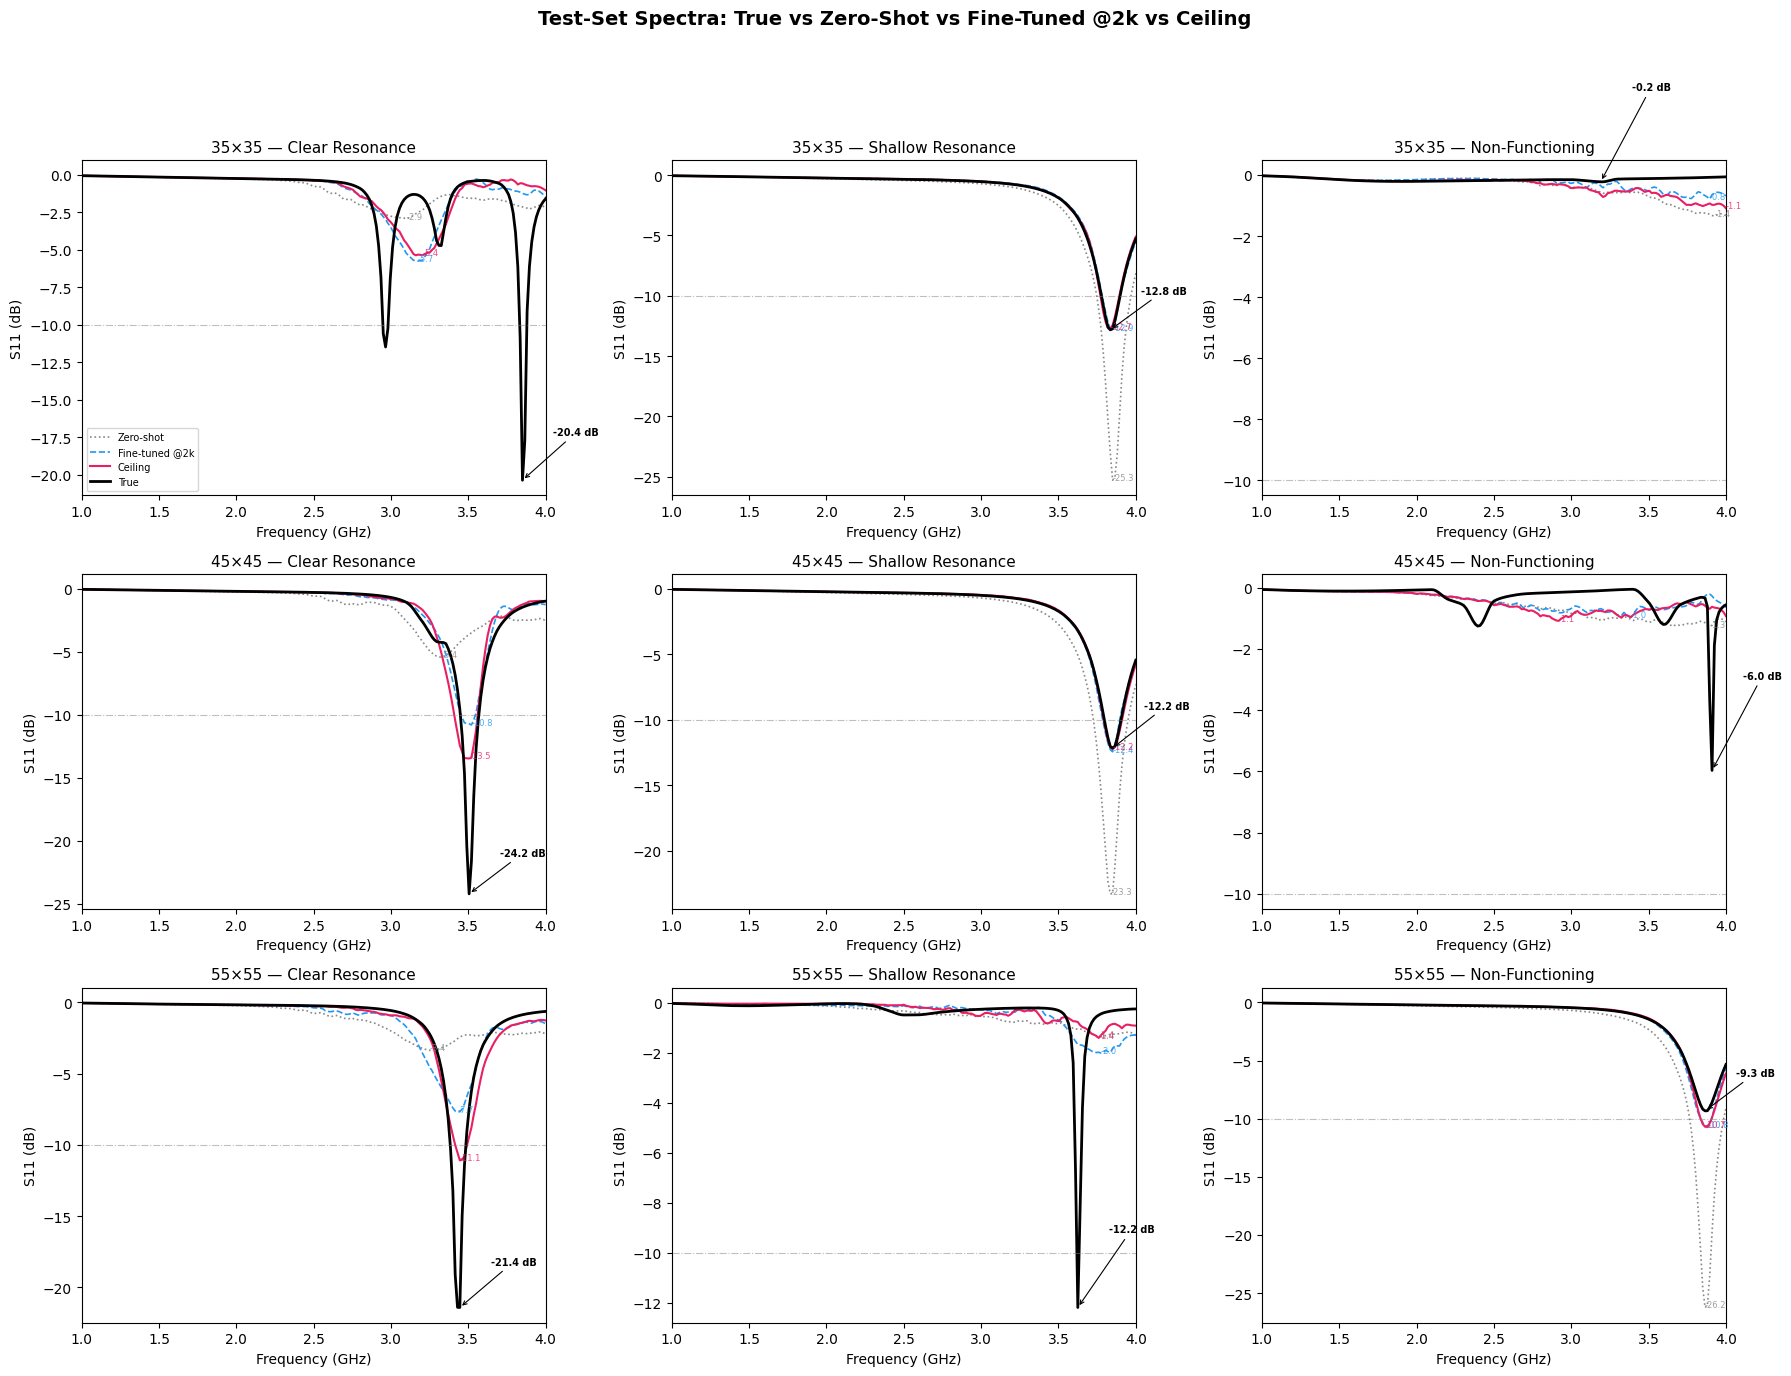

✓ Saved figures/finetuned_spectra_comparison.png
✓ Saved artifacts/finetuned_spectra_chosen_samples.json


In [13]:
# CELL H — Qualitative spectra figure
import matplotlib.pyplot as plt

# ── Build lookup structures ──
def build_per_sample_lookup(per_sample_list):
    """Index per-sample records by pos for O(1) lookup."""
    return {rec['pos']: rec for rec in per_sample_list}

zs_lookup = build_per_sample_lookup(zs_per_sample)
ft_lookup = build_per_sample_lookup(ft_per_sample)
ceil_lookup = build_per_sample_lookup(ceil_per_sample)

# Build pos -> manifest is_functioning lookup
pos_manifest_func = {}
for pos, (grid_size, sample_idx) in enumerate(test_indices):
    mask = ((manifest_df['grid_size'] == grid_size) &
            (manifest_df['sample_idx'] == sample_idx))
    match = manifest_df[mask]
    if len(match) > 0:
        pos_manifest_func[pos] = bool(match['is_functioning'].iloc[0])

# ── Deterministic sample selection ──
np.random.seed(15)
chosen_samples = {}  # {(grid, category): pos}
chosen_info = []     # for JSON artifact

for g in [35, 45, 55]:
    # Get all positions for this grid
    grid_positions = [rec['pos'] for rec in zs_per_sample if rec['grid'] == g]
    shuffled = np.random.permutation(grid_positions)

    found = {'clear': None, 'shallow': None, 'non_func': None}
    for pos in shuffled:
        rec = zs_lookup[pos]
        true_min = rec['true_s11_min']
        is_func = pos_manifest_func.get(pos, None)

        if found['clear'] is None and true_min < -20:
            found['clear'] = pos
        if found['shallow'] is None and -13 <= true_min <= -10:
            found['shallow'] = pos
        if found['non_func'] is None and is_func == False:
            found['non_func'] = pos

        if all(v is not None for v in found.values()):
            break

    for cat, pos in found.items():
        chosen_samples[(g, cat)] = pos
        # Guard BEFORE indexing. As originally written, test_indices[None]
        # raised TypeError one line before the warning could print, which
        # would have crashed the notebook after the ceiling model had
        # already trained.
        if pos is None:
            print(f'  WARNING: no {cat} sample found for grid {g} — panel skipped')
            chosen_info.append({'grid': g, 'category': cat, 'pos': None,
                                'grid_size': None, 'sample_idx': None})
            continue
        pos = int(pos)
        gi, si = test_indices[pos]
        chosen_info.append({'grid': g, 'category': cat, 'pos': pos,
                            'grid_size': gi, 'sample_idx': si})

print('Chosen samples:')
for info in chosen_info:
    print(f'  Grid {info["grid"]}, {info["category"]}: pos={info["pos"]}, '
          f'sample_idx={info["sample_idx"]}')

# ── Load actual spectra and plot ──
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
categories = ['clear', 'shallow', 'non_func']
cat_titles = {'clear': 'Clear Resonance', 'shallow': 'Shallow Resonance',
              'non_func': 'Non-Functioning'}

for row_idx, g in enumerate([35, 45, 55]):
    for col_idx, cat in enumerate(categories):
        ax = axes[row_idx, col_idx]
        pos = chosen_samples.get((g, cat))

        if pos is None:
            ax.text(0.5, 0.5, 'No sample found', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(f'{g}×{g} — {cat_titles[cat]}')
            continue

        # Load the actual spectrum data
        gi, si = test_indices[pos]
        data = torch.load(f'{processed_dir}/{gi}x{gi}/sample_{si}.pt', weights_only=False)
        true_s11 = data.y.squeeze().numpy()  # raw dB

        # Get predictions by running through models
        # Re-load models briefly for prediction extraction
        # Instead, reconstruct from per-sample + load raw for true, re-evaluate
        # Actually we need the full spectrum. Let's load and predict.
        data_norm = FinetuneDataset([(gi, si)], processed_dir, s11_mean_cpu, s11_std_cpu)
        single_loader = DataLoader(data_norm, batch_size=1, shuffle=False)
        single_batch = next(iter(single_loader)).to(device)

        # Load models for single prediction
        for mname, ckpt_path, style, color, label in [
            ('zs', f'{DATA_ROOT}/checkpoints/best_model.pt',
             ':', '#888888', 'Zero-shot'),
            ('ft', f'{DATA_ROOT}/checkpoints/strategy_A.pt',
             '--', '#2196F3', 'Fine-tuned @2k'),
            ('ceil', f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt',
             '-', '#E91E63', 'Ceiling'),
        ]:
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            tmp_model = AntennaGNN()
            tmp_model.load_state_dict(ckpt['model_state'], strict=True)
            tmp_model = tmp_model.to(device)
            tmp_model.eval()
            with torch.no_grad():
                pred_norm = tmp_model(single_batch)
                pred_db = (pred_norm * s11_std_dev + s11_mean_dev).cpu().numpy().squeeze()
            ax.plot(freq_axis, pred_db, style, color=color, label=label,
                    linewidth=1.5 if style == '-' else 1.2)

            # Annotate predicted minimum
            pred_min_idx = np.argmin(pred_db)
            pred_min_val = pred_db[pred_min_idx]
            pred_min_freq = freq_axis[pred_min_idx]
            ax.annotate(f'{pred_min_val:.1f}',
                        xy=(pred_min_freq, pred_min_val),
                        fontsize=6, color=color, alpha=0.8)
            del tmp_model, ckpt

        # True spectrum
        ax.plot(freq_axis, true_s11, '-', color='black', linewidth=2, label='True')
        true_min_idx = np.argmin(true_s11)
        true_min_val = true_s11[true_min_idx]
        true_min_freq = freq_axis[true_min_idx]
        ax.annotate(f'{true_min_val:.1f} dB',
                    xy=(true_min_freq, true_min_val),
                    xytext=(true_min_freq + 0.2, true_min_val + 3),
                    fontsize=7, color='black', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

        # -10 dB reference line
        ax.axhline(-10, color='gray', linestyle='-.', alpha=0.5, linewidth=0.8)

        ax.set_title(f'{g}×{g} — {cat_titles[cat]}', fontsize=11)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('S11 (dB)')
        ax.set_xlim(1.0, 4.0)
        if col_idx == 0 and row_idx == 0:
            ax.legend(fontsize=7, loc='lower left')

fig.suptitle('Test-Set Spectra: True vs Zero-Shot vs Fine-Tuned @2k vs Ceiling',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{DATA_ROOT}/figures/finetuned_spectra_comparison.png', dpi=300,
            bbox_inches='tight')
plt.show()
print('✓ Saved figures/finetuned_spectra_comparison.png')

# Save chosen sample info
with open(f'{DATA_ROOT}/artifacts/finetuned_spectra_chosen_samples.json', 'w') as f:
    json.dump(chosen_info, f, indent=2)
print('✓ Saved artifacts/finetuned_spectra_chosen_samples.json')

if torch.cuda.is_available():
    torch.cuda.empty_cache()

---
## CELL I — Data-Efficiency Curve

Fine-tune sample efficiency across scales against a zero-shot floor and a full-pool
ceiling. Budgets: 500 / 1,000 / 2,000 / 4,000 / full. Two points are already
trained (2,000 and full), so only 500, 1,000 and 4,000 need training.

**NOTE** this is a DIFFERENT curve from Chunk 8's. Chunk 8 plots GNN-vs-CNN data
efficiency on 25×25 (Pillar 1). This plots fine-tune sample efficiency across
scales (Pillar 3).

Subsets are drawn with `train_test_split` stratified on `str(grid_size)`,
`random_state=42` — the SAME rule Chunk 13 used. The subsets are NOT nested;
each is an independent draw at that size.

Zero-shot weighted test S11 MAE: 0.6570

Budget: 500 (500 samples)
  Subset: 500 samples


Training Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40 Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  1: loss=0.5823  w_val_mae=0.4699  lr=1.00e-04  grad_norm_median=3.926  clip_frac=100.0%


...

  Epoch 28: loss=0.4212  w_val_mae=0.3489  lr=1.25e-05  grad_norm_median=2.335  clip_frac=100.0%
  Early stopping at epoch 28
  Best val MAE: 0.3430, epochs: 28


Test @4000:   0%|          | 0/47 [00:00<?, ?it/s]

  Weighted test S11 MAE: 0.3351
    Grid 35: S11 MAE=0.3525, depth_err=5.84
    Grid 45: S11 MAE=0.3180, depth_err=5.31
    Grid 55: S11 MAE=0.3462, depth_err=5.91

Budget: full (11971 samples)
  Loading pre-trained checkpoint (ceiling_fullpool.pt)...


Test @full:   0%|          | 0/47 [00:00<?, ?it/s]

  Weighted test S11 MAE: 0.3206
    Grid 35: S11 MAE=0.3327, depth_err=5.29
    Grid 45: S11 MAE=0.3137, depth_err=5.00
    Grid 55: S11 MAE=0.3166, depth_err=5.40

✓ Saved artifacts/finetune_data_efficiency.csv


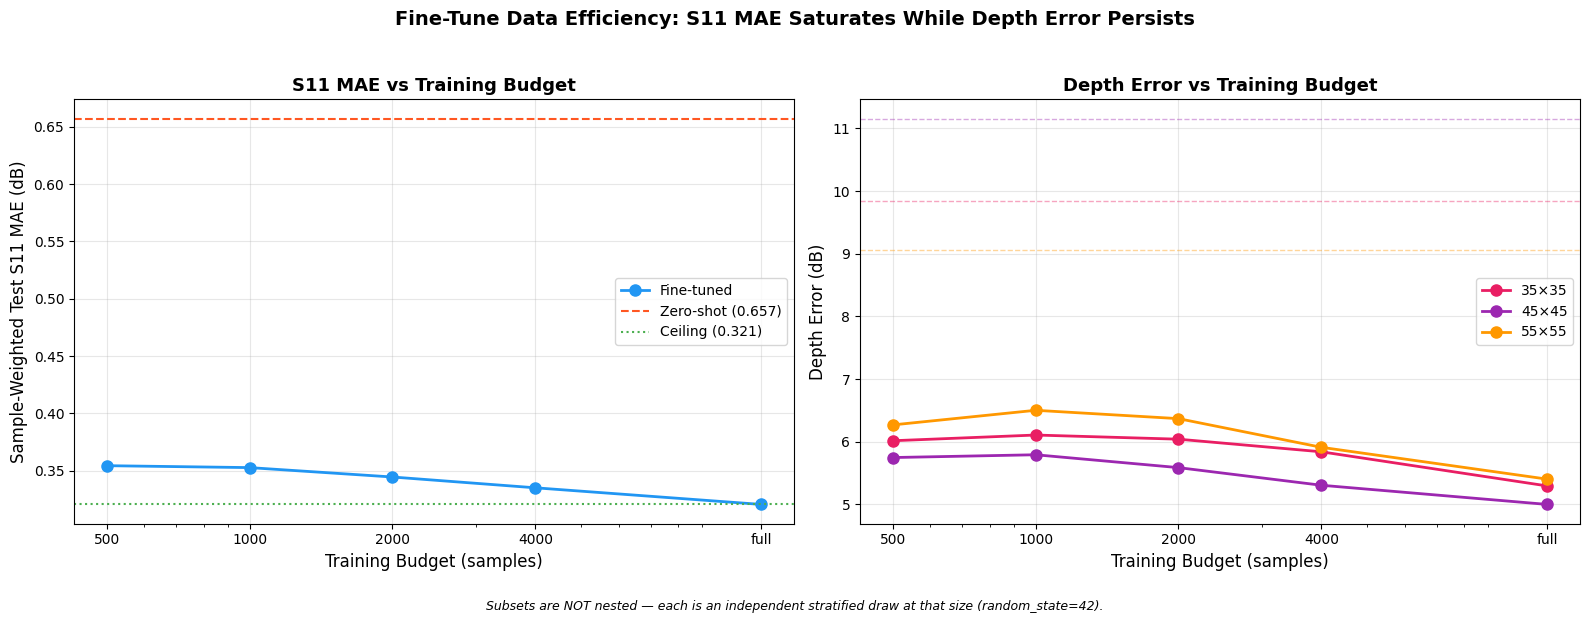

✓ Saved figures/finetune_data_efficiency.png


In [14]:
# CELL I — Data-efficiency curve
RUN_DATA_EFFICIENCY = True

if RUN_DATA_EFFICIENCY:
    import matplotlib.pyplot as plt

    budgets = [500, 1000, 2000, 4000, len(pool_indices)]
    budget_labels = ['500', '1000', '2000', '4000', 'full']

    # Results containers
    eff_results = {}  # {budget: {'weighted_s11_mae': ..., 'per_grid': {g: {'s11_mae', 'depth_error'}}, ...}}

    # ── Zero-shot reference ──
    zs_weighted = compute_weighted_val_mae(zs_metrics, test_indices)
    print(f'Zero-shot weighted test S11 MAE: {zs_weighted:.4f}')

    pool_grids = [str(g) for g, _ in pool_indices]

    for budget, label in zip(budgets, budget_labels):
        print(f'\n{"="*60}')
        print(f'Budget: {label} ({budget} samples)')
        print(f'{"="*60}')

        if budget == 2000:
            # Already trained: load strategy_A.pt
            print('  Loading pre-trained checkpoint (strategy_A.pt)...')
            ckpt = torch.load(f'{DATA_ROOT}/checkpoints/strategy_A.pt',
                              map_location='cpu', weights_only=False)
            bmodel = AntennaGNN()
            bmodel.load_state_dict(ckpt['model_state'], strict=True)
            bmodel = bmodel.to(device)
            bmodel.eval()
            b_metrics = evaluate(bmodel, test_loader, desc=f'Test @{label}')
            b_weighted = compute_weighted_val_mae(b_metrics, test_indices)
            del bmodel, ckpt

        elif budget == len(pool_indices):
            # Already trained: load ceiling_fullpool.pt
            print('  Loading pre-trained checkpoint (ceiling_fullpool.pt)...')
            ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt',
                              map_location='cpu', weights_only=False)
            bmodel = AntennaGNN()
            bmodel.load_state_dict(ckpt['model_state'], strict=True)
            bmodel = bmodel.to(device)
            bmodel.eval()
            b_metrics = evaluate(bmodel, test_loader, desc=f'Test @{label}')
            b_weighted = compute_weighted_val_mae(b_metrics, test_indices)
            del bmodel, ckpt

        else:
            # Train new model at this budget
            subset_indices, _ = train_test_split(
                pool_indices, train_size=budget,
                stratify=pool_grids, random_state=42)
            print(f'  Subset: {len(subset_indices)} samples')

            subset_ds = FinetuneDataset(subset_indices, processed_dir,
                                         s11_mean_cpu, s11_std_cpu)
            subset_loader = DataLoader(subset_ds, batch_size=32, shuffle=True)

            # Fresh model from best_model.pt
            ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                              map_location='cpu', weights_only=False)
            bmodel = AntennaGNN()
            bmodel.load_state_dict(ckpt['model_state'], strict=True)
            bmodel = bmodel.to(device)

            # Apply strategy (Strategy A: freeze=0)
            n_freeze = strategy_config.get('n_blocks_to_freeze', 0)
            if n_freeze > 0:
                freeze_early_blocks(bmodel, n_freeze)

            lr = strategy_config.get('lr', 1e-4)
            bmodel, best_mae, epochs_run, gnorms = train_finetune(
                bmodel, subset_loader, val_loader,
                epochs=40, lr=lr, patience=8, max_norm=1.0)

            print(f'  Best val MAE: {best_mae:.4f}, epochs: {epochs_run}')

            b_metrics = evaluate(bmodel, test_loader, desc=f'Test @{label}')
            b_weighted = compute_weighted_val_mae(b_metrics, test_indices)
            del bmodel, ckpt, subset_ds, subset_loader

        eff_results[budget] = {
            'label': label,
            'weighted_s11_mae': b_weighted,
            'per_grid': {g: {'s11_mae': b_metrics[g]['s11_mae'],
                             'depth_error': b_metrics[g]['depth_error']}
                         for g in [35, 45, 55]},
        }
        print(f'  Weighted test S11 MAE: {b_weighted:.4f}')
        for g in [35, 45, 55]:
            print(f'    Grid {g}: S11 MAE={b_metrics[g]["s11_mae"]:.4f}, '
                  f'depth_err={b_metrics[g]["depth_error"]:.2f}')

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ── Save CSV ──
    eff_rows = []
    for budget in budgets:
        r = eff_results[budget]
        for g in [35, 45, 55]:
            eff_rows.append({
                'budget': budget,
                'label': r['label'],
                'grid': g,
                's11_mae': r['per_grid'][g]['s11_mae'],
                'depth_error': r['per_grid'][g]['depth_error'],
            })
        eff_rows.append({
            'budget': budget,
            'label': r['label'],
            'grid': 'pooled',
            's11_mae': r['weighted_s11_mae'],
            'depth_error': np.nan,
        })
    eff_df = pd.DataFrame(eff_rows)
    eff_df.to_csv(f'{DATA_ROOT}/artifacts/finetune_data_efficiency.csv', index=False)
    print(f'\n✓ Saved artifacts/finetune_data_efficiency.csv')

    # ── Plot ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Weighted test S11 MAE
    budget_vals = [b for b in budgets]
    weighted_maes = [eff_results[b]['weighted_s11_mae'] for b in budgets]

    ax1.plot(budget_vals, weighted_maes, 'o-', color='#2196F3', linewidth=2,
             markersize=8, label='Fine-tuned')
    ax1.axhline(zs_weighted, color='#FF5722', linestyle='--', linewidth=1.5,
                label=f'Zero-shot ({zs_weighted:.3f})')
    ax1.axhline(weighted_maes[-1], color='#4CAF50', linestyle=':', linewidth=1.5,
                label=f'Ceiling ({weighted_maes[-1]:.3f})')
    ax1.set_xscale('log')
    ax1.set_xlabel('Training Budget (samples)', fontsize=12)
    ax1.set_ylabel('Sample-Weighted Test S11 MAE (dB)', fontsize=12)
    ax1.set_title('S11 MAE vs Training Budget', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(budget_vals)
    ax1.set_xticklabels(budget_labels)

    # Panel 2: Depth error per grid
    colors_grid = {35: '#E91E63', 45: '#9C27B0', 55: '#FF9800'}
    for g in [35, 45, 55]:
        depth_errs = [eff_results[b]['per_grid'][g]['depth_error'] for b in budgets]
        ax2.plot(budget_vals, depth_errs, 'o-', color=colors_grid[g], linewidth=2,
                 markersize=8, label=f'{g}×{g}')
        # Zero-shot reference
        zs_de = zs_metrics[g]['depth_error']
        ax2.axhline(zs_de, color=colors_grid[g], linestyle='--', alpha=0.4, linewidth=1)

    ax2.set_xscale('log')
    ax2.set_xlabel('Training Budget (samples)', fontsize=12)
    ax2.set_ylabel('Depth Error (dB)', fontsize=12)
    ax2.set_title('Depth Error vs Training Budget', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(budget_vals)
    ax2.set_xticklabels(budget_labels)

    fig.suptitle('Fine-Tune Data Efficiency: S11 MAE Saturates While Depth Error Persists',
                 fontsize=14, fontweight='bold')
    plt.figtext(0.5, -0.02,
                'Subsets are NOT nested — each is an independent stratified draw at that size (random_state=42).',
                ha='center', fontsize=9, style='italic')
    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.savefig(f'{DATA_ROOT}/figures/finetune_data_efficiency.png', dpi=300,
                bbox_inches='tight')
    plt.show()
    print('✓ Saved figures/finetune_data_efficiency.png')

else:
    print('RUN_DATA_EFFICIENCY = False — skipping data-efficiency curve.')

---
## CELL J — Guards

Final assertions: splits disjoint, normalization guard ran, param counts,
checkpoint provenance, evaluate() default-path contract.

In [15]:
# CELL J — Guards

# ── Assert splits pairwise disjoint ──
s_pool = set(tuple(x) for x in pool_indices)
s_val  = set(tuple(x) for x in val_indices)
s_test = set(tuple(x) for x in test_indices)

assert s_pool.isdisjoint(s_val),  'Pool ∩ Val is non-empty'
assert s_val.isdisjoint(s_test),  'Val ∩ Test is non-empty'
assert s_pool.isdisjoint(s_test), 'Pool ∩ Test is non-empty'
print('✓ Splits are pairwise disjoint')

# ── Assert normalization guard ran ──
assert NORM_GUARD_RAN is True, 'Normalization guard did NOT run in this session!'
print('✓ Normalization guard ran')

# ── Assert all three checkpoints have 587,001 parameters ──
for ckpt_name in ['best_model.pt', 'strategy_A.pt', 'ceiling_fullpool.pt']:
    ckpt = torch.load(f'{DATA_ROOT}/checkpoints/{ckpt_name}',
                      map_location='cpu', weights_only=False)
    tmp_model = AntennaGNN()
    tmp_model.load_state_dict(ckpt['model_state'], strict=True)
    n_params = sum(p.numel() for p in tmp_model.parameters())
    assert n_params == 587_001, f'{ckpt_name}: expected 587001 params, got {n_params}'
    del tmp_model, ckpt
print('✓ All three checkpoints have 587,001 parameters')

# ── Assert gnn_finetuned_multiscale.pt exists ──
multiscale_path = f'{DATA_ROOT}/checkpoints/gnn_finetuned_multiscale.pt'
assert os.path.exists(multiscale_path), f'Missing: {multiscale_path}'
print('✓ gnn_finetuned_multiscale.pt exists')

# ── Assert provenance records ──
prov_path = f'{DATA_ROOT}/artifacts/multiscale_checkpoint_provenance.json'
assert os.path.exists(prov_path), f'Missing: {prov_path}'
with open(prov_path) as f:
    prov = json.load(f)
assert prov['al_seed'] is None, f'al_seed should be null, got {prov["al_seed"]}'
assert prov['labeled_set_size'] == len(pool_indices), \
    f'labeled_set_size {prov["labeled_set_size"]} != pool size {len(pool_indices)}'
print(f'✓ Provenance: al_seed=null, labeled_set_size={prov["labeled_set_size"]}')

# ── Re-verify evaluate() default-path contract ──
_guard_ds = FinetuneDataset(val_indices[:32], processed_dir, s11_mean_cpu, s11_std_cpu)
_guard_loader = DataLoader(_guard_ds, batch_size=32, shuffle=False)
_guard_ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                          map_location='cpu', weights_only=False)
_guard_model = AntennaGNN()
_guard_model.load_state_dict(_guard_ckpt['model_state'], strict=True)
_guard_model = _guard_model.to(device)
_guard_res = evaluate(_guard_model, _guard_loader, desc='guard check')
assert isinstance(_guard_res, dict), f'evaluate() default path must return dict'
for _g in _guard_res:
    assert 's11_mae' in _guard_res[_g]
    assert 'freq_mae' in _guard_res[_g]
    assert 'class_acc' in _guard_res[_g]
del _guard_ds, _guard_loader, _guard_model, _guard_ckpt, _guard_res
print('✓ evaluate() default-path contract verified (dict with s11_mae, freq_mae, class_acc)')

print('\n✓ All guards passed.')

✓ Splits are pairwise disjoint
✓ Normalization guard ran
✓ All three checkpoints have 587,001 parameters
✓ gnn_finetuned_multiscale.pt exists
✓ Provenance: al_seed=null, labeled_set_size=11971


guard check:   0%|          | 0/1 [00:00<?, ?it/s]

✓ evaluate() default-path contract verified (dict with s11_mae, freq_mae, class_acc)

✓ All guards passed.
